# About Datasets

The datasets was obtained from https://www.kaggle.com/datasets/hassanelfattmi/why-do-customers-leave-can-you-spot-the-churners/data

**Business Problem**

- IBM Telco is a company focused on B2B and B2C sector for Telecommuncations Industry. On dataset was mentioned that approximately 26.5% of customers were classified as churned, indicating that a significant portion of its customers discontinued their services during the observed period. 

**Business Questions**
- What customer characteristics and behaviors are associated with customer churn?


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from datetime import timedelta
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import squarify
from IPython.display import Markdown, display

#

# Import Library

In [69]:
raw_data = pd.read_csv(r"C:\Users\LENOVO\Desktop\Data Analyst\Dibimbing\Portfolio Project\credit_card_customer_churn_dataset.csv")
raw_data.shape

(100000, 40)

# Data Info

In [70]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   customer_id                 100000 non-null  str    
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  str    
 3   marital_status              100000 non-null  str    
 4   education_level             100000 non-null  str    
 5   employment_status           100000 non-null  str    
 6   income                      100000 non-null  float64
 7   city                        100000 non-null  str    
 8   credit_score                100000 non-null  int64  
 9   account_age_months          100000 non-null  int64  
 10  card_type                   100000 non-null  str    
 11  credit_limit                100000 non-null  float64
 12  annual_fee                  100000 non-null  int64  
 13  interest_rate             

In [71]:
raw_data["customer_id"].nunique()

100000

In [72]:
raw_data["gender"].value_counts()

gender
Female    49193
Male      48794
Other      2013
Name: count, dtype: int64

# Data Quality

## Handling Duplicate Value 

In [73]:
raw_data.duplicated().sum()

np.int64(0)

## Handling Missing Value 


In [74]:
missing_percentage = (
    raw_data.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(missing_percentage)

customer_id                   0.0
age                           0.0
gender                        0.0
marital_status                0.0
education_level               0.0
employment_status             0.0
income                        0.0
city                          0.0
credit_score                  0.0
account_age_months            0.0
card_type                     0.0
credit_limit                  0.0
annual_fee                    0.0
interest_rate                 0.0
num_products                  0.0
has_loan                      0.0
has_savings_account           0.0
monthly_spending              0.0
avg_transaction_amount        0.0
monthly_transactions          0.0
online_transactions           0.0
international_transactions    0.0
cash_withdrawals              0.0
utilization_ratio             0.0
payment_delay_count           0.0
late_payment_amount           0.0
app_logins_monthly            0.0
website_visits_monthly        0.0
customer_service_calls        0.0
complaints_cou

In [75]:
binary_cols = [
    "has_loan",
    "has_savings_account",
    "churned"
]

for col in binary_cols:
    print(f"\n{col}")
    print(raw_data[col].value_counts())


has_loan
has_loan
0    64950
1    35050
Name: count, dtype: int64

has_savings_account
has_savings_account
1    59842
0    40158
Name: count, dtype: int64

churned
churned
0    80542
1    19458
Name: count, dtype: int64


## Handling Outlier

- Outlier Treatment

The IQR method was applied to numerical variables to identify statistical outliers. ["Churn Flag"] was excluded because it is a binary categorical variable rather than a continuous numerical measure. No statistical outliers were identified among the remaining numerical variables.

In [76]:
numeric_cols = raw_data.select_dtypes(
    include="number"
).columns.tolist()

In [77]:
outlier_summary = []

for col in numeric_cols:
    Q1 = raw_data[col].quantile(0.25)
    Q3 = raw_data[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (
        (raw_data[col] < lower_bound) |
        (raw_data[col] > upper_bound)
    ).sum()
    
    outlier_percentage = outliers / len(raw_data) * 100
    
    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers,
        "Outlier %": round(outlier_percentage, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "Outlier %",
    ascending=False
)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
32,churned,0.0000,0.0000,0.0000,0.00000,0.00000,19458,19.46
18,late_payment_amount,0.0000,15.0000,15.0000,-22.50000,37.50000,15431,15.43
14,international_transactions,0.0000,7.0000,7.0000,-10.50000,17.50000,10793,10.79
31,churn_probability,0.0428,0.2612,0.2184,-0.28480,0.58880,8166,8.17
30,churn_risk_score,4.2800,26.1200,21.8400,-28.48000,58.88000,8166,8.17
5,annual_fee,0.0000,150.0000,150.0000,-225.00000,375.00000,7123,7.12
24,reward_points,2323.0000,8905.0000,6582.0000,-7550.00000,18778.00000,6826,6.83
10,monthly_spending,2073.8050,7773.4550,5699.6500,-6475.67000,16322.93000,6757,6.76
4,credit_limit,7700.0000,23100.0000,15400.0000,-15400.00000,46200.00000,5908,5.91
22,complaints_count,0.0000,1.0000,1.0000,-1.50000,2.50000,5446,5.45


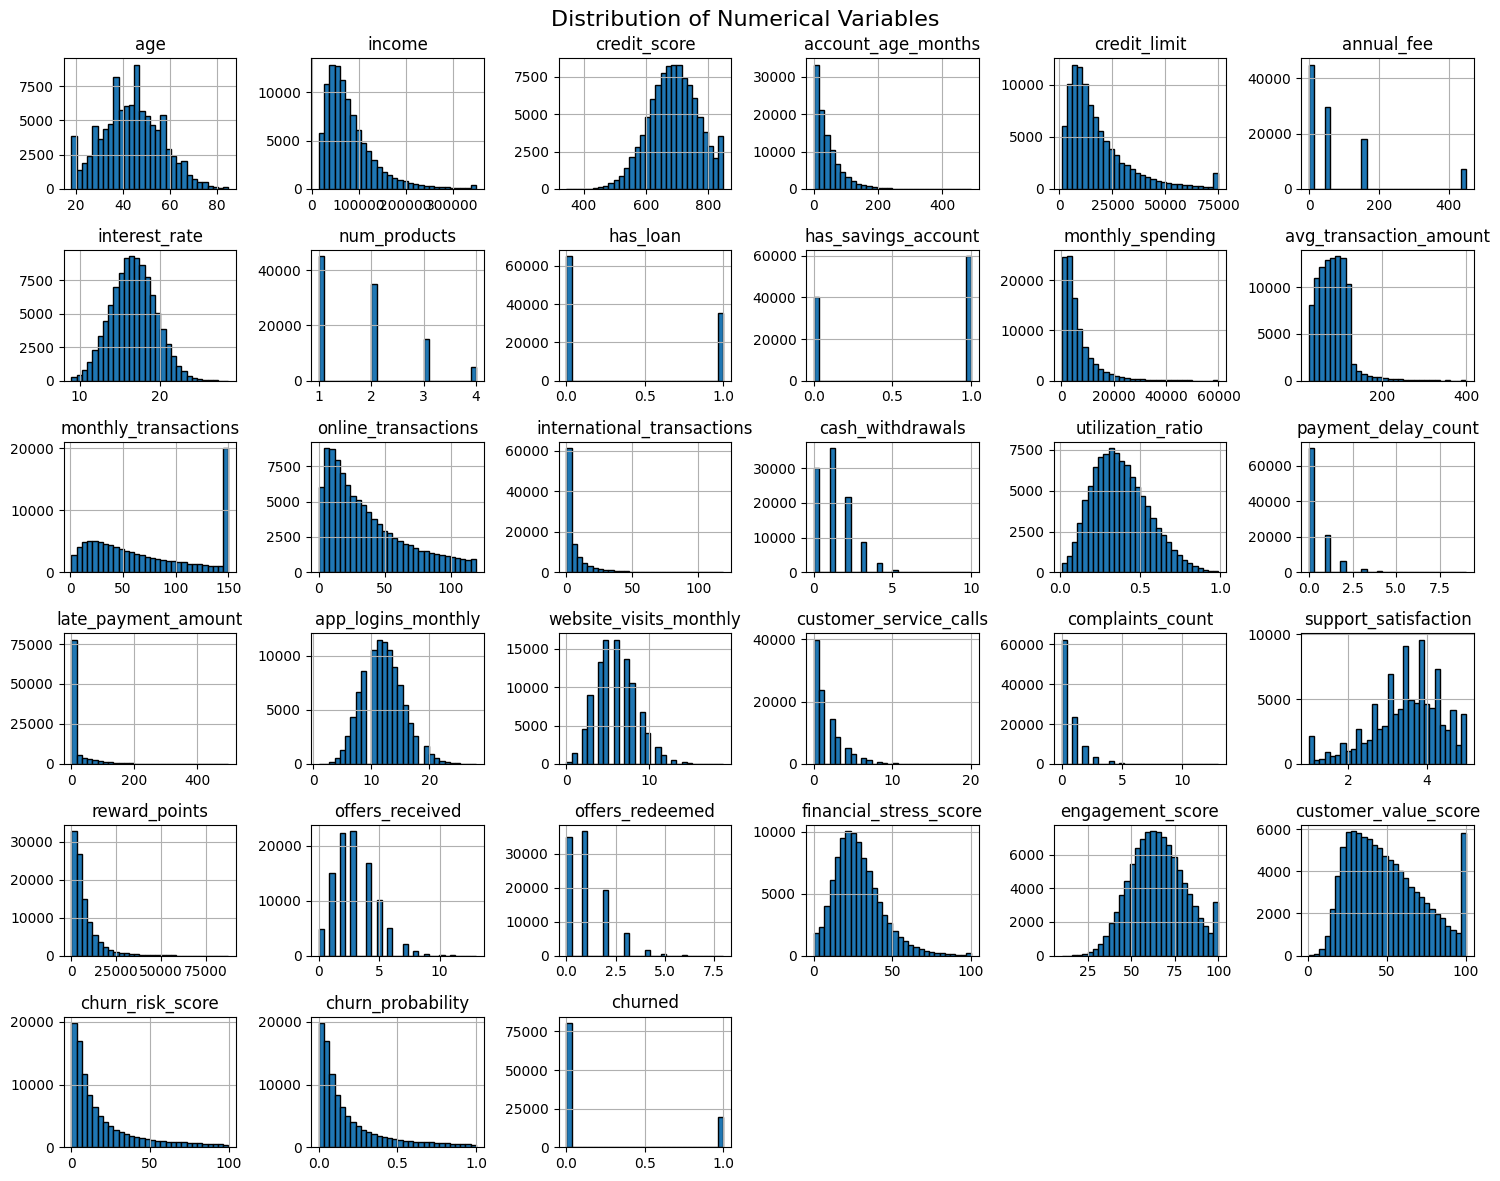

In [78]:
raw_data[numeric_cols].hist(
    bins=30,
    figsize=(15, 12),
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

In [184]:
check_cols = [
    "late_payment_amount",
    "international_transactions",
    "annual_fee",
    "reward_points",
    "monthly_spending",
    "credit_limit",
    "income",
    "account_age_months"
]

raw_data[check_cols].agg(["min", "max"]).T

,min,max
late_payment_amount,0.0,500.0
international_transactions,0.0,119.0
annual_fee,0.0,450.0
reward_points,40.0,87409.0
monthly_spending,50.0,60000.0
credit_limit,1000.0,75000.0
income,15000.0,350000.0
account_age_months,1.0,490.0


In [185]:
skewness = (
    raw_data[numeric_cols]
    .skew()
    .to_frame("Skewness")
    .sort_values("Skewness", ascending=False)
)
skewness["Abs Skewness"] = skewness["Skewness"].abs()
skewness

,Skewness,Abs Skewness
late_payment_amount,4.528415,4.528415
international_transactions,3.105145,3.105145
reward_points,2.786231,2.786231
monthly_spending,2.589413,2.589413
payment_delay_count,2.340173,2.340173
annual_fee,2.280672,2.280672
complaints_count,2.218833,2.218833
customer_service_calls,2.053168,2.053168
account_age_months,1.982537,1.982537
income,1.822202,1.822202


## Data Manipulation

- account_age_months contains 5,278 records (5.28%) that are inconsistent with customer age. The issue is concentrated among younger customers, with a median age of 18 years. Since the actual account opening date is unavailable, these values cannot be reliably reconstructed. Therefore, the affected records are retained while account_age_months is excluded from the primary churn analysis.

In [271]:
logical_check = raw_data[
    (raw_data["account_age_months"] / 12) > (raw_data["age"] - 18)
]

logical_check[
    ["customer_id", "age", "account_age_months"]
].sort_values(
    "account_age_months",
    ascending=False
).head(20)

,customer_id,age,account_age_months
87771,CUST-0087772,48,490
60130,CUST-0060131,54,451
25994,CUST-0025995,34,413
97855,CUST-0097856,25,401
38314,CUST-0038315,38,393
34301,CUST-0034302,49,389
32503,CUST-0032504,31,380
88733,CUST-0088734,42,369
22988,CUST-0022989,32,368
23915,CUST-0023916,30,351


In [187]:
raw_data["account_age_years"] = raw_data["account_age_months"] / 12

invalid_account_age = raw_data[
    raw_data["account_age_years"] > (raw_data["age"] - 18)
]

print("Invalid records:", len(invalid_account_age))
print("Percentage:", len(invalid_account_age) / len(raw_data) * 100)

Invalid records: 5278
Percentage: 5.2780000000000005


In [188]:
invalid_account_age[
    ["customer_id", "age", "account_age_months", "account_age_years"]
].sort_values(
    "account_age_months",
    ascending=False
).head(20)

,customer_id,age,account_age_months,account_age_years
87771,CUST-0087772,48,490,40.833333
60130,CUST-0060131,54,451,37.583333
25994,CUST-0025995,34,413,34.416667
97855,CUST-0097856,25,401,33.416667
38314,CUST-0038315,38,393,32.750000
34301,CUST-0034302,49,389,32.416667
32503,CUST-0032504,31,380,31.666667
88733,CUST-0088734,42,369,30.750000
22988,CUST-0022989,32,368,30.666667
23915,CUST-0023916,30,351,29.250000


In [190]:
raw_data["account_age_invalid"] = (
    raw_data["account_age_years"] > (raw_data["age"] - 18)
)

In [191]:
raw_data["account_age_invalid"].value_counts()

account_age_invalid
False    94722
True      5278
Name: count, dtype: int64

In [192]:
invalid_account_age[
    ["age", "account_age_months"]
].describe()

,age,account_age_months
count,5278.000000,5278.000000
mean,20.805608,74.885373
std,4.325109,66.118954
min,18.000000,1.000000
25%,18.000000,25.000000
50%,18.000000,55.000000
75%,22.000000,108.000000
max,54.000000,490.000000


In [193]:
raw_data.groupby("account_age_invalid")[
    ["age", "account_age_months"]
].mean()

,age,account_age_months
account_age_invalid,,
False,44.906569,40.628851
True,20.805608,74.885373


In [194]:
df_analysis = raw_data.drop(
    columns=[
        "account_age_months",
        "account_age_years",
        "account_age_invalid"
    ]
).copy()

# Save to CSV after Cleaning

In [195]:
df_analysis.to_csv("customer_churn_cleaned.csv", index=False)

# Reload File after Cleaning

In [2]:
data_after_cleaning = pd.read_csv(r"C:\Users\LENOVO\Desktop\Data Analyst\Dibimbing\Portfolio Project\customer_churn_cleaned.csv")
data_after_cleaning.shape

(100000, 39)

# Exploratory Data Analysis

In [3]:
df = data_after_cleaning.copy()

## KPI Dashboard

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   customer_id                 100000 non-null  str    
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  str    
 3   marital_status              100000 non-null  str    
 4   education_level             100000 non-null  str    
 5   employment_status           100000 non-null  str    
 6   income                      100000 non-null  float64
 7   city                        100000 non-null  str    
 8   credit_score                100000 non-null  int64  
 9   card_type                   100000 non-null  str    
 10  credit_limit                100000 non-null  float64
 11  annual_fee                  100000 non-null  int64  
 12  interest_rate               100000 non-null  float64
 13  num_products              

In [5]:

# Customer
total_customers = df["customer_id"].nunique()

# Churn
churned_customers = (df["churned"] == 1).sum()
churn_rate = churned_customers / total_customers

#Active Customer 
active_customers = (df["churned"] == 0).sum() 
active_rate = active_customers / total_customers

# ============================================================
# MARKDOWN KPI DASHBOARD
# ============================================================

markdown_table = f"""
## Credit Card Churn KPIs

| KPI | Value |
|:---|---:|
| 👥 **Total Customers** | {total_customers:,} |
| 🔴 **Churned Customers** | {churned_customers:,} |
| 📉 **Churn Rate** | {churn_rate:.1%} |
| 👤 **Active Customers** | {active_customers:,} |
| 📈 **Active Customers Rate** | {active_rate:.1%} |
"""

display(Markdown(markdown_table))


## Credit Card Churn KPIs

| KPI | Value |
|:---|---:|
| 👥 **Total Customers** | 100,000 |
| 🔴 **Churned Customers** | 19,458 |
| 📉 **Churn Rate** | 19.5% |
| 👤 **Active Customers** | 80,542 |
| 📈 **Active Customers Rate** | 80.5% |


## Churn Distribution 

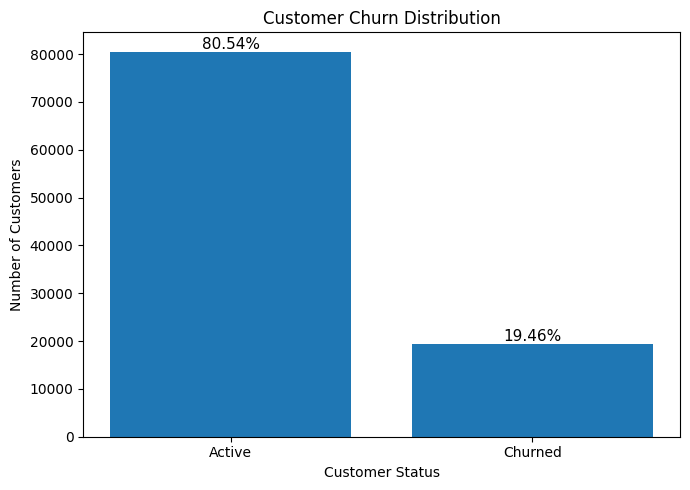

In [6]:
churn_counts = df["churned"].value_counts()
total_customers = churn_counts.sum()
active_count = churn_counts.get(0, 0)
churned_count = churn_counts.get(1, 0)

active_pct = active_count / total_customers * 100
churned_pct = churned_count / total_customers * 100


plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Active", "Churned"],
    [active_count, churned_count]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")


for bar, pct in zip(bars, [active_pct, churned_pct]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()


## Churn Overview
    - *Who are our customers?*

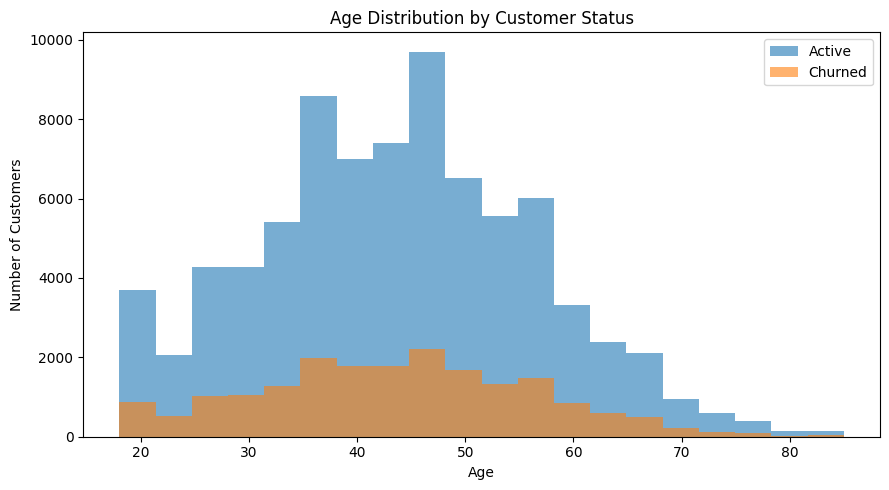

In [7]:
# Age - Customer Age Distribution
plt.figure(figsize=(9, 5))

plt.hist(
    df[df["churned"] == 0]["age"],
    bins=20,
    alpha=0.6,
    label="Active"
)

plt.hist(
    df[df["churned"] == 1]["age"],
    bins=20,
    alpha=0.6,
    label="Churned"
)

plt.title("Age Distribution by Customer Status")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ]
)

In [9]:
age_churn = (
    df.groupby("age_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

age_churn["churn_rate"] *= 100

age_churn

,age_group,customers,churned,churn_rate
0,18-25,8261,1602,19.392325
1,26-35,18615,3587,19.269406
2,36-45,29248,5678,19.413293
3,46-55,25974,5055,19.461769
4,56-65,13335,2671,20.029996
5,66+,4567,865,18.940223


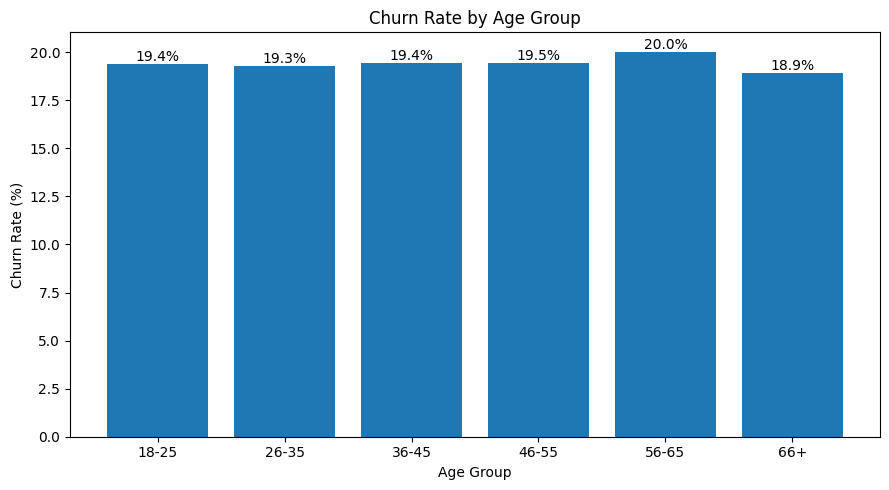

In [11]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    age_churn["age_group"].astype(str),
    age_churn["churn_rate"]
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(bars, age_churn["churn_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [10]:
# Income vs Churn Rate 
df["income_group"] = pd.qcut(
    df["income"],
    q=5,
    labels=[
        "Lowest Income",
        "Lower-Middle Income",
        "Middle Income",
        "Upper-Middle Income",
        "Highest Income"
    ]
)

In [12]:
income_churn = (
    df.groupby("income_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

income_churn["churn_rate"] *= 100

income_churn

,income_group,customers,churned,churn_rate
0,Lowest Income,20000,3946,19.730
1,Lower-Middle Income,20000,3819,19.095
2,Middle Income,20000,3910,19.550
3,Upper-Middle Income,20000,3905,19.525
4,Highest Income,20000,3878,19.390


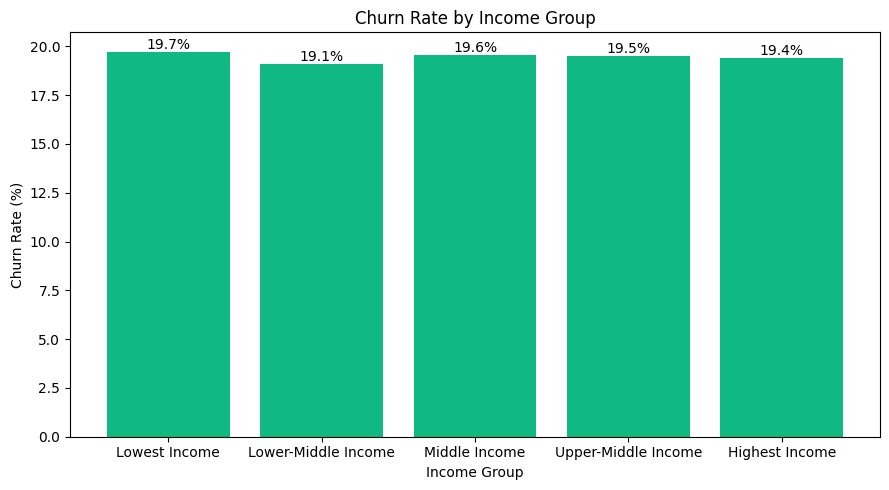

In [13]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    income_churn["income_group"].astype(str),
    income_churn["churn_rate"],
    color="#10B981"
)

plt.title("Churn Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(bars, income_churn["churn_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [14]:
# Employment Status 
employment_churn = (
    df.groupby("employment_status")["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

employment_churn["churn_rate"] *= 100

employment_churn.sort_values(
    "churn_rate",
    ascending=False
)

,employment_status,customers,churned,churn_rate
3,Student,5002,1014,20.271891
4,Unemployed,7930,1558,19.646910
0,Employed,62082,12100,19.490351
1,Retired,9947,1908,19.181663
2,Self-Employed,15039,2878,19.136911


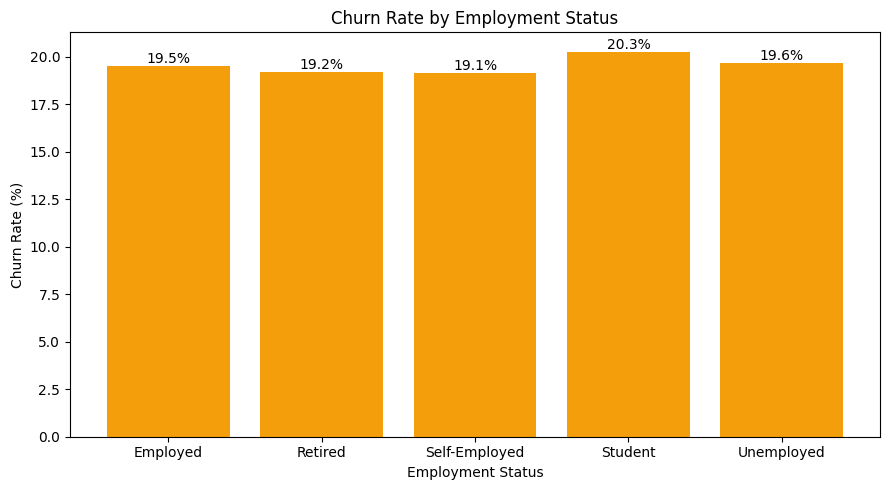

In [15]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    employment_churn["employment_status"].astype(str),
    employment_churn["churn_rate"],
    color="#F59E0B"
)

plt.title("Churn Rate by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(bars, employment_churn["churn_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [16]:
# Marital Status 
marital_churn = (
    df.groupby("marital_status")["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

marital_churn["churn_rate"] *= 100

marital_churn.sort_values(
    "churn_rate",
    ascending=False
)

,marital_status,customers,churned,churn_rate
1,Married,48091,9375,19.494292
2,Single,34995,6810,19.459923
0,Divorced,11865,2303,19.410029
3,Widowed,5049,970,19.211725


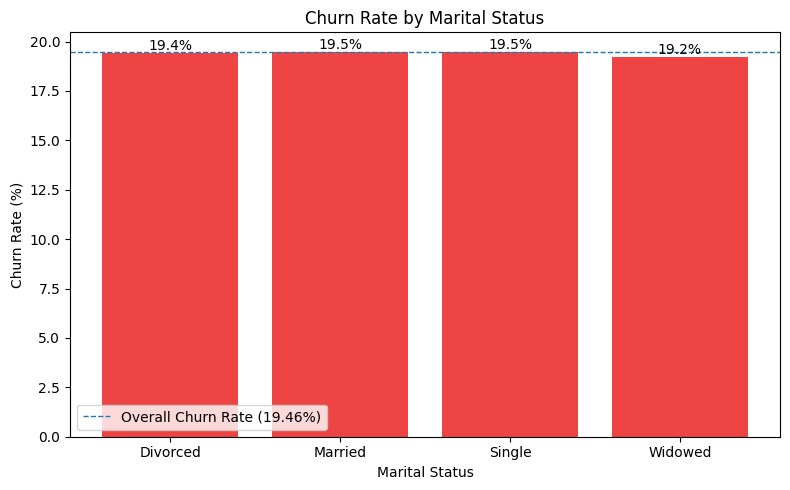

In [17]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    marital_churn["marital_status"],
    marital_churn["churn_rate"],
    color="#EF4444"
)

plt.title("Churn Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(bars, marital_churn["churn_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.axhline(
    y=19.46,
    linestyle="--",
    linewidth=1,
    label="Overall Churn Rate (19.46%)"
)

plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Educational Level 
education_churn = (
    df.groupby("education_level")["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

education_churn["churn_rate"] *= 100

education_churn.sort_values(
    "churn_rate",
    ascending=False
)

,education_level,customers,churned,churn_rate
3,High School,24953,4955,19.857332
2,Doctorate,4968,985,19.826892
4,Master,15032,2921,19.431879
0,Associate,15110,2913,19.278623
1,Bachelor,39937,7684,19.240303


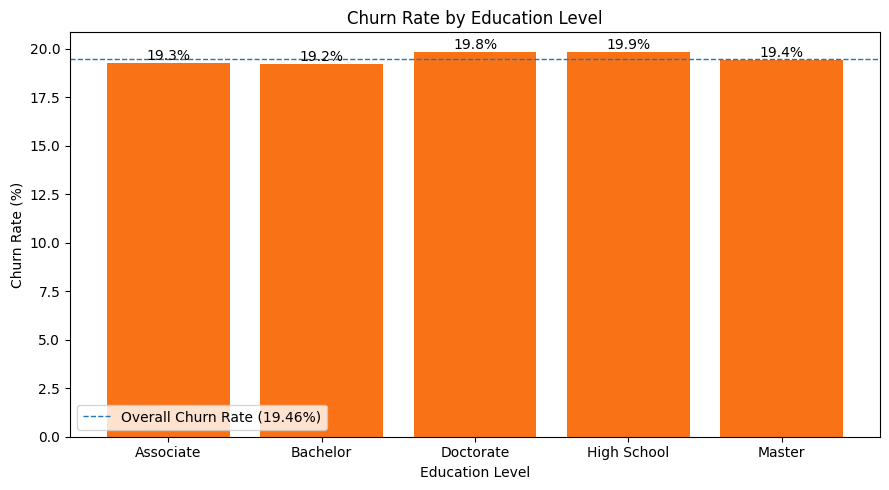

In [19]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    education_churn["education_level"],
    education_churn["churn_rate"],
    color= "#F97316"
)

plt.title("Churn Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    education_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.axhline(
    y=19.46,
    linestyle="--",
    linewidth=1,
    label="Overall Churn Rate (19.46%)"
)

plt.legend()
plt.tight_layout()
plt.show()

## Credit & Financial Profile

In [20]:
# Credit Score
# Using FICO Score 
# Fico Score is  is a three-digit number ranging from 300 to 850 that represents your credit risk. 
df["credit_score_group"] = pd.cut(
    df["credit_score"],
    bins=[0, 579, 669, 739, 799, 850],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Exceptional"
    ]
)

In [21]:
credit_churn = (
    df.groupby("credit_score_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

credit_churn["churn_rate"] *= 100

credit_churn

,credit_score_group,customers,churned,churn_rate
0,Poor,8388,2135,25.453028
1,Fair,31722,6923,21.823971
2,Good,33134,6161,18.594193
3,Very Good,18300,3003,16.409836
4,Exceptional,8456,1236,14.616840


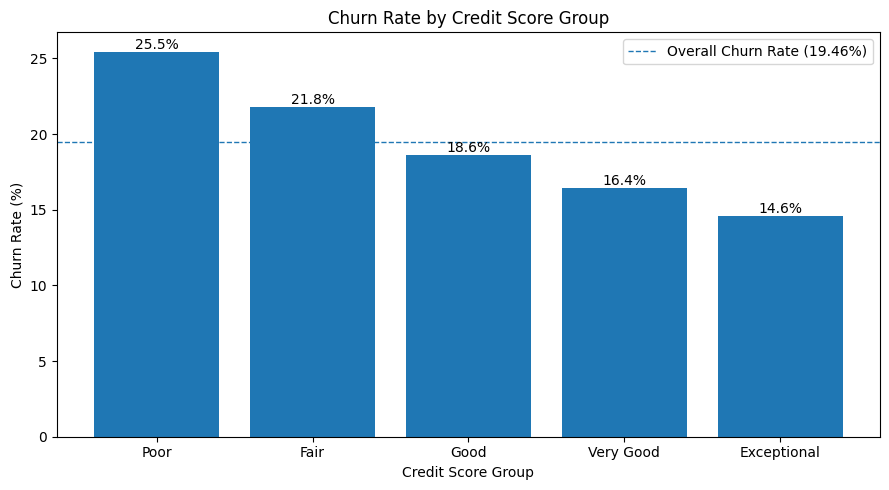

In [22]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    credit_churn["credit_score_group"].astype(str),
    credit_churn["churn_rate"]
)

plt.title("Churn Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    credit_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.axhline(
    y=19.46,
    linestyle="--",
    linewidth=1,
    label="Overall Churn Rate (19.46%)"
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Credit score shows a substantially stronger relationship with observed churn rates than the demographic variables analyzed previously. Customers in the Poor credit-score group have a 25.45% churn rate, compared with 14.62% among customers in the Exceptional group. The observed churn rate decreases progressively as credit-score category increases.

In [23]:
# Credit Limit vs Churn 
df["credit_limit_group"] = pd.qcut(
    df["credit_limit"],
    q=5,
    labels=[
        "Lowest Credit Limit",
        "Lower-Middle Credit Limit",
        "Middle Credit Limit",
        "Upper-Middle Credit Limit",
        "Highest Credit Limit"
    ]
)

In [24]:
credit_limit_churn = (
    df.groupby("credit_limit_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

credit_limit_churn["churn_rate"] *= 100

credit_limit_churn

,credit_limit_group,customers,churned,churn_rate
0,Lowest Credit Limit,20139,4000,19.861959
1,Lower-Middle Credit Limit,20146,3928,19.497667
2,Middle Credit Limit,19862,3799,19.126976
3,Upper-Middle Credit Limit,19983,3846,19.246359
4,Highest Credit Limit,19870,3885,19.552089


In [25]:
credit_limit_range = (
    df.groupby("credit_limit_group", observed=False)["credit_limit"]
      .agg(
          min="min",
          median="median",
          max="max"
      )
      .reset_index()
)

credit_limit_range

,credit_limit_group,min,median,max
0,Lowest Credit Limit,1000.0,4600.0,6700.0
1,Lower-Middle Credit Limit,6800.0,8800.0,10900.0
2,Middle Credit Limit,11000.0,13400.0,16400.0
3,Upper-Middle Credit Limit,16500.0,20600.0,26500.0
4,Highest Credit Limit,26600.0,37600.0,75000.0


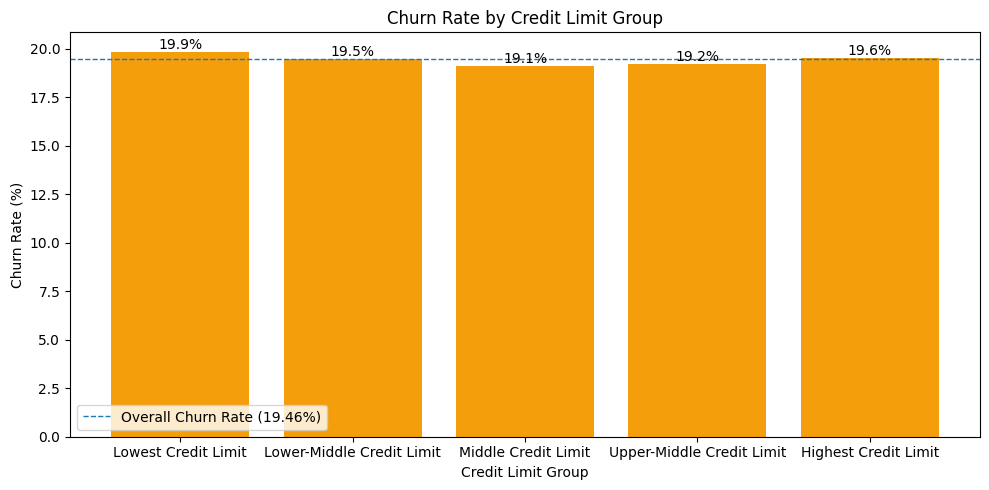

In [26]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    credit_limit_churn["credit_limit_group"].astype(str),
    credit_limit_churn["churn_rate"],
    color = "#F59E0B"
)

plt.title("Churn Rate by Credit Limit Group")
plt.xlabel("Credit Limit Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    credit_limit_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.axhline(
    y=19.46,
    linestyle="--",
    linewidth=1,
    label="Overall Churn Rate (19.46%)"
)

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# Utilization Ratio
df["utilization_ratio"].describe()

count    100000.000000
mean          0.378698
std           0.172453
min           0.010000
25%           0.250000
50%           0.361000
75%           0.491000
max           0.990000
Name: utilization_ratio, dtype: float64

In [28]:
df["utilization_group"] = pd.qcut(
    df["utilization_ratio"],
    q=4,
    labels=[
        "Lowest Utilization",
        "Lower-Middle Utilization",
        "Upper-Middle Utilization",
        "Highest Utilization"
    ]
)

In [29]:
utilization_churn = (
    df.groupby("utilization_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

utilization_churn["churn_rate"] *= 100

utilization_churn

,utilization_group,customers,churned,churn_rate
0,Lowest Utilization,25168,3648,14.494596
1,Lower-Middle Utilization,24979,4459,17.850995
2,Upper-Middle Utilization,24932,4920,19.733676
3,Highest Utilization,24921,6431,25.805546


In [30]:
utilization_range = (
    df.groupby("utilization_group", observed=False)["utilization_ratio"]
      .agg(
          min="min",
          median="median",
          max="max"
      )
      .reset_index()
)

utilization_range

,utilization_group,min,median,max
0,Lowest Utilization,0.010,0.185,0.250
1,Lower-Middle Utilization,0.251,0.307,0.361
2,Upper-Middle Utilization,0.362,0.421,0.491
3,Highest Utilization,0.492,0.589,0.990


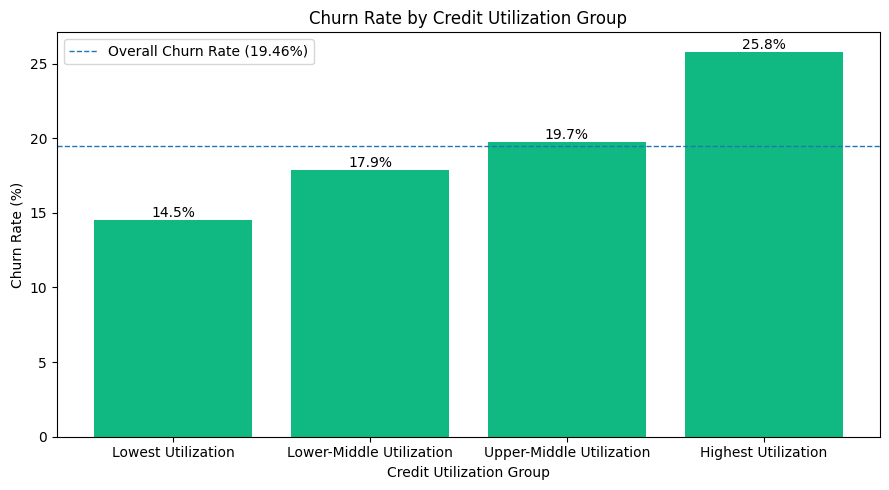

In [31]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    utilization_churn["utilization_group"].astype(str),
    utilization_churn["churn_rate"],
    color = "#10B981"
)

plt.title("Churn Rate by Credit Utilization Group")
plt.xlabel("Credit Utilization Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    utilization_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.axhline(
    y=19.46,
    linestyle="--",
    linewidth=1,
    label="Overall Churn Rate (19.46%)"
)

plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# Interest Rate

df["interest_rate_group"] = pd.qcut(
    df["interest_rate"],
    q=4,
    labels=[
        "Lowest Interest Rate",
        "Lower-Middle Interest Rate",
        "Upper-Middle Interest Rate",
        "Highest Interest Rate"
    ]
)

In [33]:
interest_churn = (
    df.groupby("interest_rate_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

interest_churn["churn_rate"] *= 100

interest_churn

,interest_rate_group,customers,churned,churn_rate
0,Lowest Interest Rate,25009,4034,16.130193
1,Lower-Middle Interest Rate,25069,4603,18.361323
2,Upper-Middle Interest Rate,24969,5084,20.361248
3,Highest Interest Rate,24953,5737,22.991224


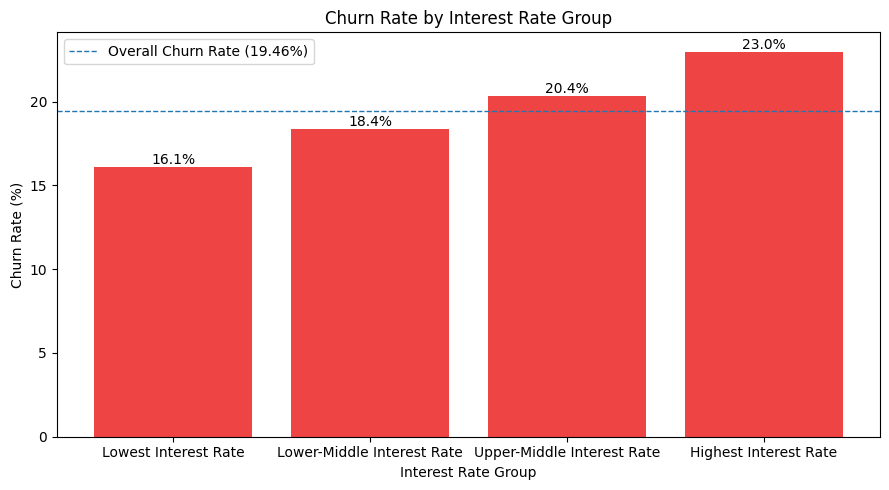

In [34]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    interest_churn["interest_rate_group"].astype(str),
    interest_churn["churn_rate"],
    color = "#EF4444"
)

plt.title("Churn Rate by Interest Rate Group")
plt.xlabel("Interest Rate Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    interest_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.axhline(
    y=19.46,
    linestyle="--",
    linewidth=1,
    label="Overall Churn Rate (19.46%)"
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Observed churn rates increase progressively across interest-rate groups. Customers in the highest interest-rate quartile have a 22.99% churn rate, compared with 16.13% among customers in the lowest quartile. This represents a 6.86 percentage-point difference.

In [35]:
#Loan & Savings Account
loan_churn = (
    df.groupby("has_loan")["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

loan_churn["churn_rate"] *= 100

loan_churn

,has_loan,customers,churned,churn_rate
0,0,64950,12590,19.384142
1,1,35050,6868,19.594864


In [36]:
savings_churn = (
    df.groupby("has_savings_account")["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

savings_churn["churn_rate"] *= 100

savings_churn

,has_savings_account,customers,churned,churn_rate
0,0,40158,7783,19.380945
1,1,59842,11675,19.509709


## Customer Transaction Behavior

In [37]:
# Monthly Spending
df["monthly_spending_group"] = pd.qcut(
    df["monthly_spending"],
    q=5,
    labels=[
        "Lowest Spending",
        "Lower-Middle Spending",
        "Middle Spending",
        "Upper-Middle Spending",
        "Highest Spending"
    ]
)

In [38]:
spending_churn = (
    df.groupby("monthly_spending_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

spending_churn["churn_rate"] *= 100

spending_churn

,monthly_spending_group,customers,churned,churn_rate
0,Lowest Spending,20000,3377,16.885
1,Lower-Middle Spending,20000,3655,18.275
2,Middle Spending,20000,3821,19.105
3,Upper-Middle Spending,20000,4074,20.370
4,Highest Spending,20000,4531,22.655


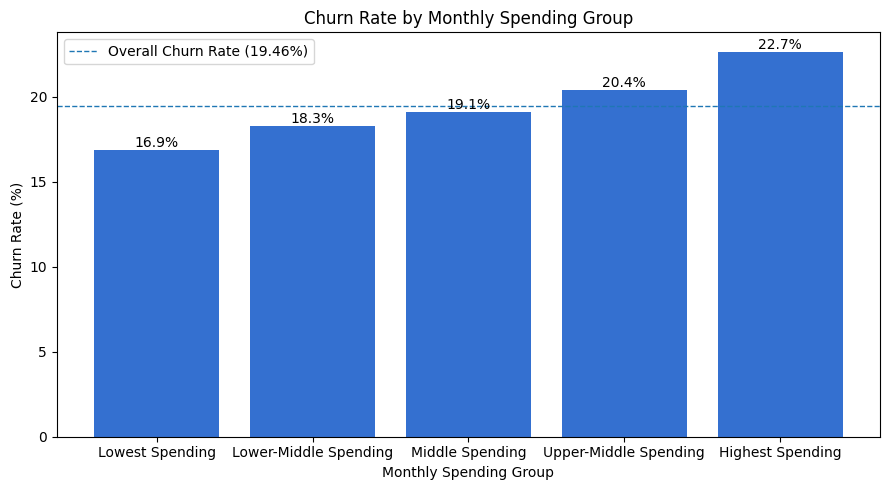

In [39]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    spending_churn["monthly_spending_group"].astype(str),
    spending_churn["churn_rate"],
    color = "#3470D0"
)

plt.title("Churn Rate by Monthly Spending Group")
plt.xlabel("Monthly Spending Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    spending_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.axhline(
    y=19.46,
    linestyle="--",
    linewidth=1,
    label="Overall Churn Rate (19.46%)"
)

plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# Average Transaction Count
df["avg_transaction_group"] = pd.qcut(
    df["avg_transaction_amount"],
    q=5,
    labels=[
        "Lowest Transaction Value",
        "Lower-Middle Transaction Value",
        "Middle Transaction Value",
        "Upper-Middle Transaction Value",
        "Highest Transaction Value"
    ]
)

In [41]:
avg_transaction_churn = (
    df.groupby("avg_transaction_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

avg_transaction_churn["churn_rate"] *= 100

avg_transaction_churn

,avg_transaction_group,customers,churned,churn_rate
0,Lowest Transaction Value,20000,3738,18.690000
1,Lower-Middle Transaction Value,20007,3809,19.038337
2,Middle Transaction Value,20006,3911,19.549135
3,Upper-Middle Transaction Value,19996,3867,19.338868
4,Highest Transaction Value,19991,4133,20.674303


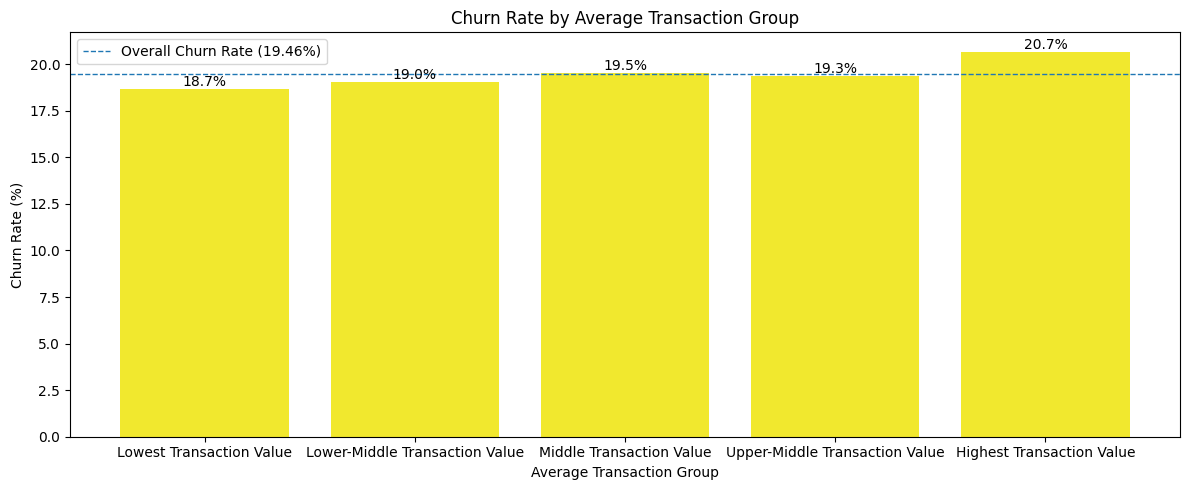

In [42]:
plt.figure(figsize=(12, 5))

bars = plt.bar(
    avg_transaction_churn["avg_transaction_group"].astype(str),
    avg_transaction_churn["churn_rate"],
    color = "#F1E82E"
)

plt.title("Churn Rate by Average Transaction Group")
plt.xlabel("Average Transaction Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    avg_transaction_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.axhline(
    y=19.46,
    linestyle="--",
    linewidth=1,
    label="Overall Churn Rate (19.46%)"
)

plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# Monthly Transactions 
df["monthly_transactions"].describe()

count    100000.000000
mean         73.055180
std          50.678979
min           1.000000
25%          29.000000
50%          60.000000
75%         123.000000
max         150.000000
Name: monthly_transactions, dtype: float64

In [44]:
df["monthly_transactions"].value_counts().sort_index().tail(15)

monthly_transactions
136      218
137      215
138      204
139      208
140      199
141      198
142      190
143      186
144      180
145      184
146      188
147      176
148      174
149      160
150    19364
Name: count, dtype: int64

In [45]:
(df["monthly_transactions"] == 150).sum()

np.int64(19364)

In [46]:
df["monthly_transactions_group"] = pd.cut(
    df["monthly_transactions"],
    bins=[0, 30, 60, 90, 120, 149, 150],
    labels=[
        "1-30",
        "31-60",
        "61-90",
        "91-120",
        "121-149",
        "150"
    ],
    include_lowest=True
)

In [47]:
transaction_freq_churn = (
    df.groupby(
        "monthly_transactions_group",
        observed=False
    )["churned"]
    .agg(
        customers="count",
        churned="sum",
        churn_rate="mean"
    )
    .reset_index()
)

transaction_freq_churn["churn_rate"] *= 100

transaction_freq_churn

,monthly_transactions_group,customers,churned,churn_rate
0,1-30,26881,4667,17.361705
1,31-60,23423,4295,18.336678
2,61-90,14612,2908,19.901451
3,91-120,9531,2007,21.057602
4,121-149,6189,1247,20.148651
5,150,19364,4334,22.381739


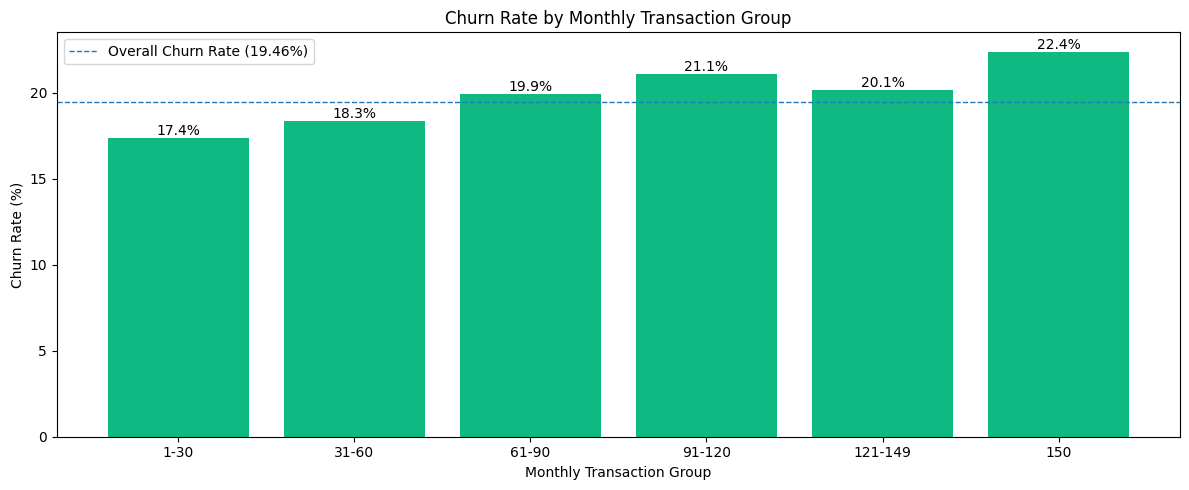

In [48]:
plt.figure(figsize=(12, 5))

bars = plt.bar(
    transaction_freq_churn["monthly_transactions_group"].astype(str),
    transaction_freq_churn["churn_rate"],
    color = "#10B981"
)

plt.title("Churn Rate by Monthly Transaction Group")
plt.xlabel("Monthly Transaction Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    transaction_freq_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.axhline(
    y=19.46,
    linestyle="--",
    linewidth=1,
    label="Overall Churn Rate (19.46%)"
)

plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# Online Transactions 
df["online_transactions_group"] = pd.qcut(
    df["online_transactions"],
    q=5,
    labels=[
        "Lowest Online Transactions",
        "Lower-Middle Online Transactions",
        "Middle Online Transactions",
        "Upper-Middle Online Transactions",
        "Highest Online Transactions"
    ]
)

In [50]:
online_transaction_churn = (
    df.groupby(
        "online_transactions_group",
        observed=False
    )["churned"]
    .agg(
        customers="count",
        churned="sum",
        churn_rate="mean"
    )
    .reset_index()
)

online_transaction_churn["churn_rate"] *= 100

online_transaction_churn

,online_transactions_group,customers,churned,churn_rate
0,Lowest Online Transactions,21361,3687,17.260428
1,Lower-Middle Online Transactions,18667,3380,18.106820
2,Middle Online Transactions,20825,4033,19.366146
3,Upper-Middle Online Transactions,19477,4054,20.814294
4,Highest Online Transactions,19670,4304,21.881037


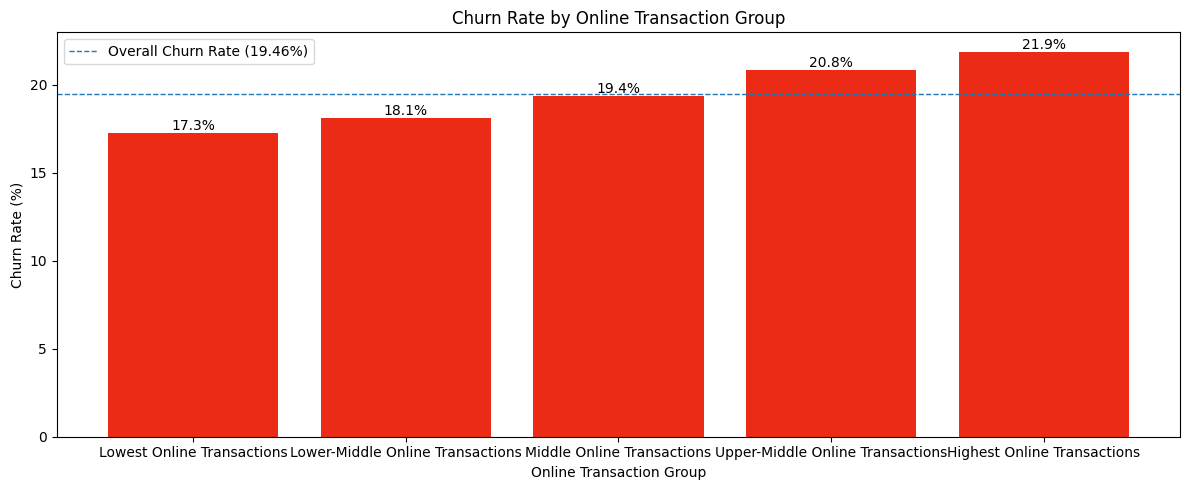

In [52]:
plt.figure(figsize=(12, 5))

bars = plt.bar(
    online_transaction_churn["online_transactions_group"].astype(str),
    online_transaction_churn["churn_rate"],
    color = "#EB2B15"
)

plt.title("Churn Rate by Online Transaction Group")
plt.xlabel("Online Transaction Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    online_transaction_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.axhline(
    y=19.46,
    linestyle="--",
    linewidth=1,
    label="Overall Churn Rate (19.46%)"
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# International Transactions 
df["international_transactions"].describe()

count    100000.000000
mean          6.267300
std          10.959182
min           0.000000
25%           0.000000
50%           2.000000
75%           7.000000
max         119.000000
Name: international_transactions, dtype: float64

In [58]:
bins = [-1, 0, 2, 5, 10, float("inf")]

labels = [
    "0",
    "1–2",
    "3–5",
    "6–10",
    ">10"
]

df["international_transactions_group"] = pd.cut(
    df["international_transactions"],
    bins=bins,
    labels=labels
)

In [83]:
international_churn = (
    df.groupby("international_transactions_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

international_churn["churn_rate"] *= 100

international_churn

,international_transactions_group,customers,churned,churn_rate
0,0,36048,6753,18.733356
1,1–2,19601,3732,19.039845
2,3–5,13971,2780,19.898361
3,6–10,11692,2322,19.859733
4,>10,18688,3871,20.713827


In [64]:
# cash withdrawals 
df["cash_withdrawals"].describe()

count    100000.000000
mean          1.204380
std           1.100482
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          10.000000
Name: cash_withdrawals, dtype: float64

In [87]:
bins = [-1, 0, 1, 2, 3, 4, float("inf")]

labels = [
    "0",
    "1",
    "2",
    "3",
    "4",
    "5+"
]

df["cash_withdrawals_group"] = pd.cut(
    df["cash_withdrawals"],
    bins=bins,
    labels=labels
)

In [88]:
cash_withdrawal_churn = (
    df.groupby("cash_withdrawals_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
    .reset_index()
)

cash_withdrawal_churn["churn_rate"] *= 100
cash_withdrawal_churn

,cash_withdrawals_group,customers,churned,churn_rate
0,0,30159,5862,19.436984
1,1,35878,7064,19.688946
2,2,21777,4152,19.065987
3,3,8707,1721,19.765706
4,4,2685,511,19.031657
5,5+,794,148,18.639798


In [82]:
# Payment Delay Count
df["payment_delay_count"].describe()

count    100000.000000
mean          0.428790
std           0.781675
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           9.000000
Name: payment_delay_count, dtype: float64

In [89]:
# Late Payment
df["late_payment_amount"].describe()

count    100000.000000
mean         19.710776
std          50.401669
min           0.000000
25%           0.000000
50%           0.000000
75%          15.000000
max         500.000000
Name: late_payment_amount, dtype: float64

In [90]:
bins = [-1, 0, 15, 50, 100, float("inf")]

labels = [
    "0",
    "1–15",
    "16–50",
    "51–100",
    ">100"
]

df["late_payment_amount_group"] = pd.cut(
    df["late_payment_amount"],
    bins=bins,
    labels=labels
)

In [91]:
late_payment_churn = (
    df.groupby("late_payment_amount_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

late_payment_churn["churn_rate"] *= 100

late_payment_churn

,late_payment_amount_group,customers,churned,churn_rate
0,0,70059,8728,12.458071
1,1–15,7077,2213,31.270312
2,16–50,10273,3446,33.544242
3,51–100,6754,2405,35.608528
4,>100,5837,2666,45.674148


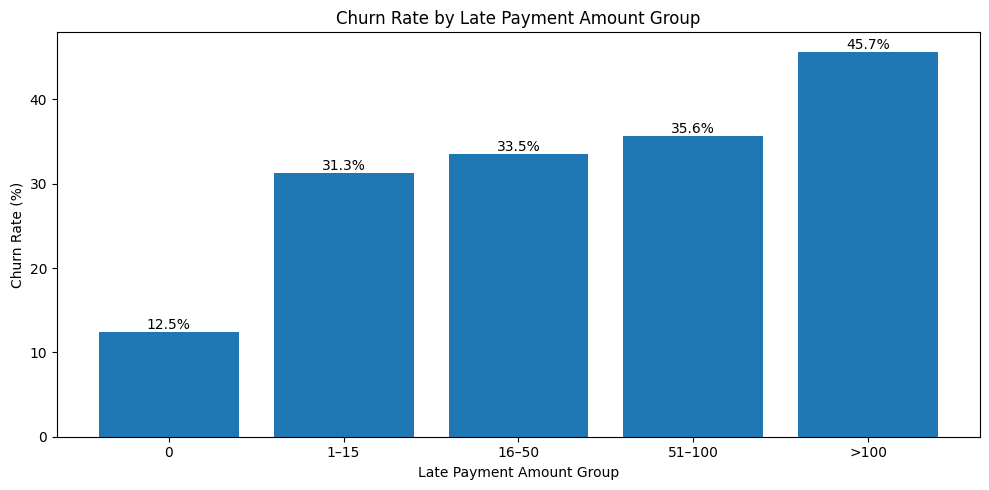

In [93]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    late_payment_churn["late_payment_amount_group"].astype(str),
    late_payment_churn["churn_rate"],
    color="#1f77b4"
)

plt.title("Churn Rate by Late Payment Amount Group")
plt.xlabel("Late Payment Amount Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    late_payment_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Engagement & Customer Experience

In [94]:
# App-Logins Motnhly
df["app_logins_monthly"].describe()

count    100000.000000
mean         12.000270
std           3.471013
min           1.000000
25%          10.000000
50%          12.000000
75%          14.000000
max          28.000000
Name: app_logins_monthly, dtype: float64

In [95]:
bins = [0, 7, 10, 14, 18, float("inf")]

labels = [
    "<8",
    "8–10",
    "11–14",
    "15–18",
    ">18"
]

df["app_logins_group"] = pd.cut(
    df["app_logins_monthly"],
    bins=bins,
    labels=labels
)

In [96]:
app_login_churn = (
    df.groupby("app_logins_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

app_login_churn["churn_rate"] *= 100

app_login_churn

,app_logins_group,customers,churned,churn_rate
0,<8,8964,2387,26.628737
1,8–10,25794,5806,22.509111
2,11–14,42356,7876,18.594768
3,15–18,19084,2910,15.248376
4,>18,3802,479,12.598632


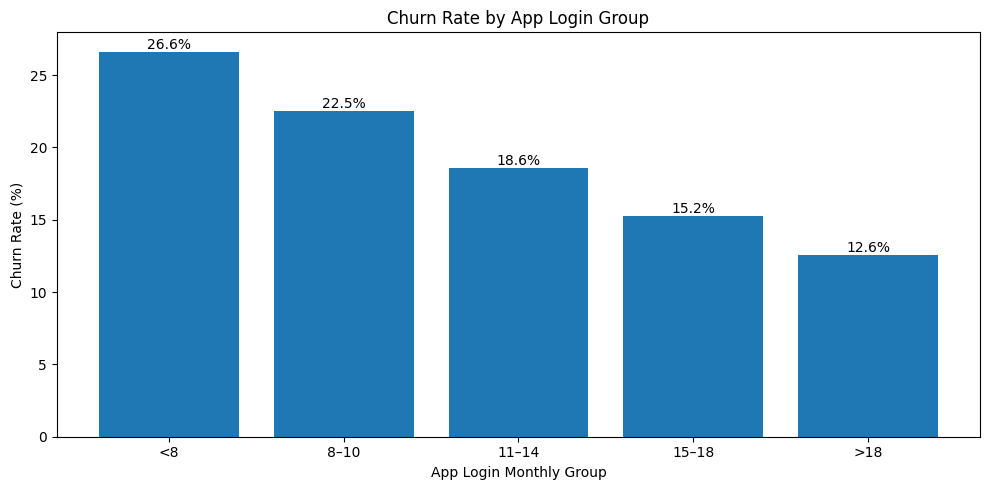

In [99]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    app_login_churn["app_logins_group"].astype(str),
    app_login_churn["churn_rate"],
    color="#1f77b4"
)

plt.title("Churn Rate by App Login Group")
plt.xlabel("App Login Monthly Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    app_login_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [100]:
# Web Visits Monthly
df["website_visits_monthly"].describe()

count    100000.00000
mean          5.99688
std           2.43803
min           0.00000
25%           4.00000
50%           6.00000
75%           8.00000
max          19.00000
Name: website_visits_monthly, dtype: float64

In [101]:
bins = [-1, 2, 4, 6, 8, float("inf")]

labels = [
    "0–2",
    "3–4",
    "5–6",
    "7–8",
    ">8"
]

df["website_visits_group"] = pd.cut(
    df["website_visits_monthly"],
    bins=bins,
    labels=labels
)

In [102]:
website_visit_churn = (
    df.groupby("website_visits_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

website_visit_churn["churn_rate"] *= 100

website_visit_churn

,website_visits_group,customers,churned,churn_rate
0,0–2,6168,1445,23.427367
1,3–4,22210,4550,20.486267
2,5–6,32293,6339,19.629641
3,7–8,24288,4583,18.869401
4,>8,15041,2541,16.893824


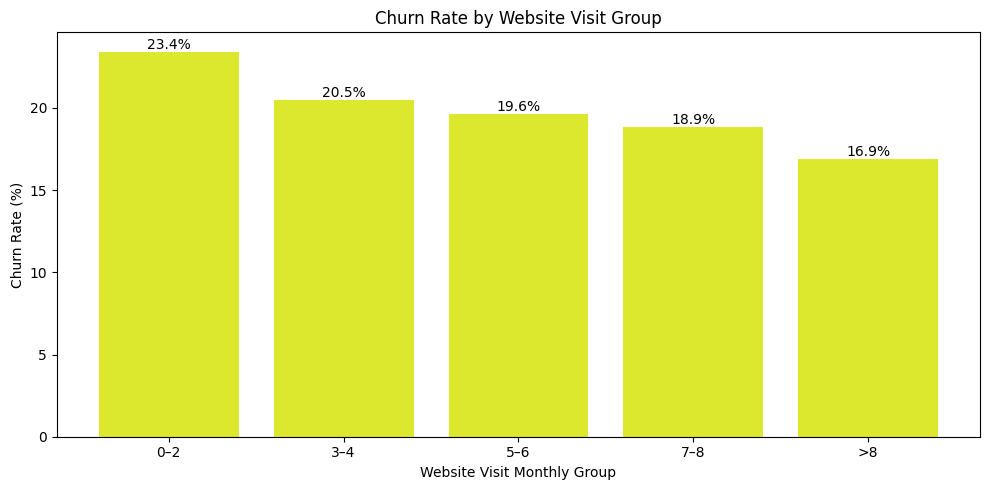

In [103]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    website_visit_churn["website_visits_group"].astype(str),
    website_visit_churn["churn_rate"],
    color="#dce82e"
)

plt.title("Churn Rate by Website Visit Group")
plt.xlabel("Website Visit Monthly Group")
plt.ylabel("Churn Rate (%)")

for bar, rate in zip(
    bars,
    website_visit_churn["churn_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# customer service calls
df["customer_service_calls"].describe()

count    100000.000000
mean          1.502990
std           1.933553
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          20.000000
Name: customer_service_calls, dtype: float64

In [106]:
bins = [-1, 0, 1, 2, 3, float("inf")]

labels = [
    "0",
    "1",
    "2",
    "3",
    "4+"
]

df["customer_service_calls_group"] = pd.cut(
    df["customer_service_calls"],
    bins=bins,
    labels=labels
)

In [107]:
service_call_churn = (
    df.groupby("customer_service_calls_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

service_call_churn["churn_rate"] *= 100

service_call_churn

,customer_service_calls_group,customers,churned,churn_rate
0,0,39947,5505,13.780760
1,1,23873,4032,16.889373
2,2,14482,3033,20.943240
3,3,8650,2181,25.213873
4,4+,13048,4707,36.074494


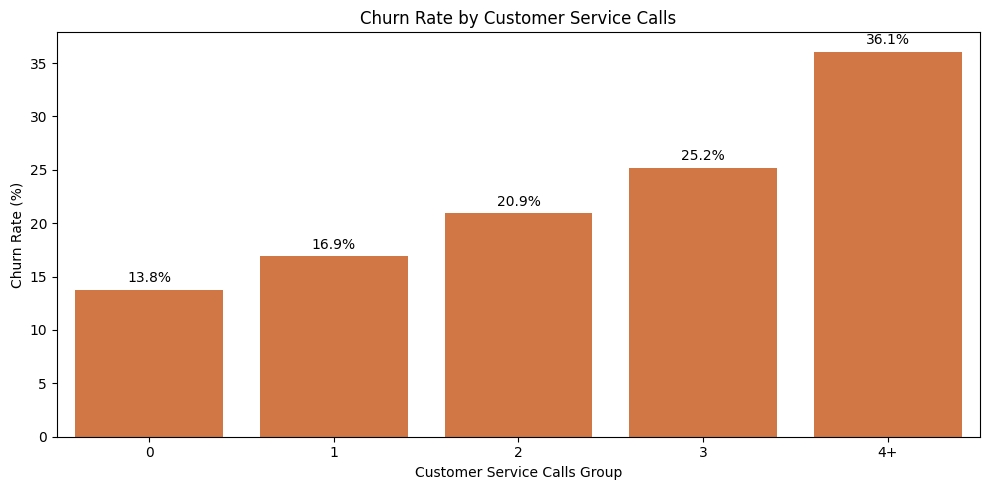

In [114]:
plt.figure(figsize=(10, 5))

bars = sns.barplot(
    data=service_call_churn,
    x="customer_service_calls_group",
    y="churn_rate",
    color="#e86f2e"
)

plt.title("Churn Rate by Customer Service Calls")
plt.xlabel("Customer Service Calls Group")
plt.ylabel("Churn Rate (%)")

for container in bars.containers:
    bars.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [115]:
#complains count
df["complaints_count"].describe()

count    100000.000000
mean          0.604860
std           0.984548
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          13.000000
Name: complaints_count, dtype: float64

In [117]:
bins = [-1, 0, 1, 2, 3, float("inf")]

labels = [
    "0",
    "1",
    "2",
    "3",
    "4+"
]

df["complaints_count_group"] = pd.cut(
    df["complaints_count"],
    bins=bins,
    labels=labels
)

In [118]:
complaints_count_churn = (
    df.groupby("complaints_count_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

complaints_count_churn["churn_rate"] *= 100
complaints_count_churn

,complaints_count_group,customers,churned,churn_rate
0,0,62355,8583,13.764734
1,1,23439,5199,22.180980
2,2,8760,2859,32.636986
3,3,3407,1535,45.054300
4,4+,2039,1282,62.873958


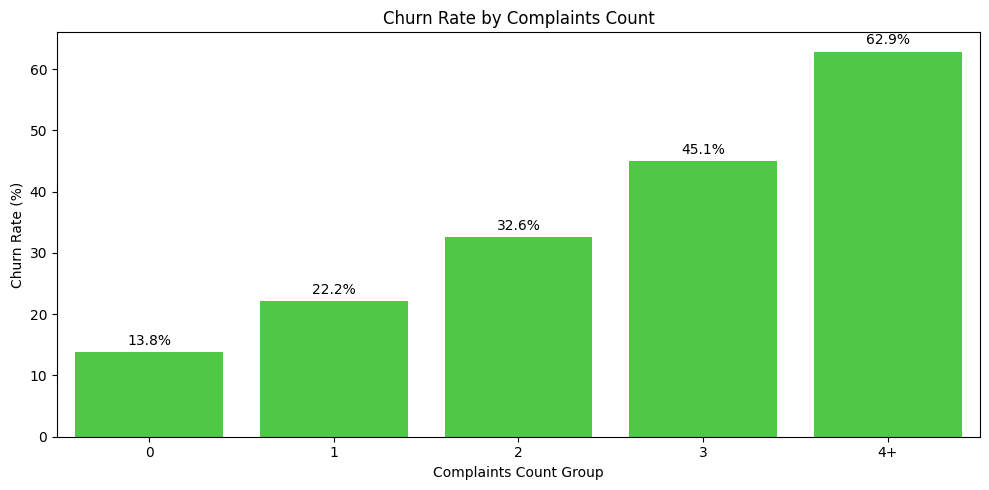

In [120]:
plt.figure(figsize=(10, 5))

bars = sns.barplot(
    data=complaints_count_churn,
    x="complaints_count_group",
    y="churn_rate",
    color="#3bde30"
)

plt.title("Churn Rate by Complaints Count")
plt.xlabel("Complaints Count Group")
plt.ylabel("Churn Rate (%)")

for container in bars.containers:
    bars.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [122]:
# Supports Satisfaction
df["support_satisfaction"].describe()

count    100000.000000
mean          3.454744
std           0.890964
min           1.000000
25%           2.900000
50%           3.600000
75%           4.100000
max           5.000000
Name: support_satisfaction, dtype: float64

In [127]:
df["support_satisfaction_group"] = df["support_satisfaction"].astype(int)
support_satisfaction_churn = (
    df.groupby("support_satisfaction_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

support_satisfaction_churn["churn_rate"] *= 100

support_satisfaction_churn

,support_satisfaction_group,customers,churned,churn_rate
0,1,6761,3611,53.409259
1,2,18630,5757,30.901771
2,3,43307,7183,16.586233
3,4,28612,2739,9.572906
4,5,2690,168,6.245353


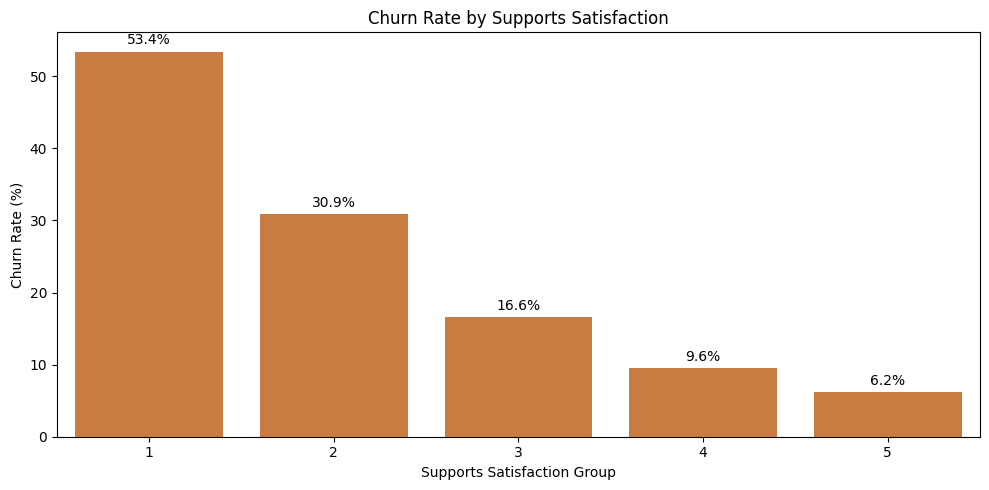

In [128]:
plt.figure(figsize=(10, 5))

bars = sns.barplot(
    data=support_satisfaction_churn,
    x="support_satisfaction_group",
    y="churn_rate",
    color="#e0792a"
)

plt.title("Churn Rate by Supports Satisfaction")
plt.xlabel("Supports Satisfaction Group")
plt.ylabel("Churn Rate (%)")

for container in bars.containers:
    bars.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [129]:
# Engagement Score
df["engagement_score"].describe()

count    100000.000000
mean         65.245465
std          15.570877
min          10.010000
25%          54.090000
50%          64.550000
75%          75.750000
max         100.000000
Name: engagement_score, dtype: float64

In [130]:
bins = [0, 40, 60, 80, 100]

labels = [
    "<40",
    "40–60",
    "60–80",
    "80–100"
]

df["engagement_score_group"] = pd.cut(
    df["engagement_score"],
    bins=bins,
    labels=labels
)

In [131]:
engagement_churn = (
    df.groupby("engagement_score_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

engagement_churn["churn_rate"] *= 100

engagement_churn

,engagement_score_group,customers,churned,churn_rate
0,<40,4521,1707,37.757133
1,40–60,34266,9227,26.927567
2,60–80,43253,6991,16.163041
3,80–100,17960,1533,8.535635


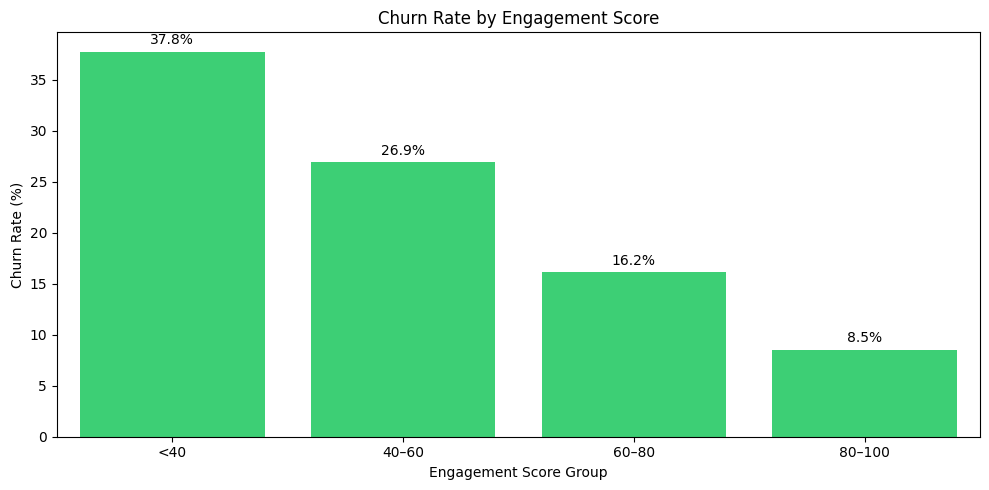

In [132]:
plt.figure(figsize=(10, 5))

bars = sns.barplot(
    data=engagement_churn,
    x="engagement_score_group",
    y="churn_rate",
    color="#24e86f"
)

plt.title("Churn Rate by Engagement Score")
plt.xlabel("Engagement Score Group")
plt.ylabel("Churn Rate (%)")

for container in bars.containers:
    bars.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [133]:
# Offers Received
df["offers_received"].describe()

count    100000.000000
mean          3.001990
std           1.729241
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          13.000000
Name: offers_received, dtype: float64

In [135]:
bins = [-1, 0, 2, 4, 6, float("inf")]

labels = [
    "0",
    "1–2",
    "3–4",
    "5–6",
    "7+"
]

df["offers_received_group"] = pd.cut(
    df["offers_received"],
    bins=bins,
    labels=labels
)

In [136]:
offers_received_churn = (
    df.groupby("offers_received_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

offers_received_churn["churn_rate"] *= 100
offers_received_churn

,offers_received_group,customers,churned,churn_rate
0,0,4910,1145,23.319756
1,1–2,37225,7840,21.061115
2,3–4,39422,7404,18.781391
3,5–6,15135,2591,17.119260
4,7+,3308,478,14.449819


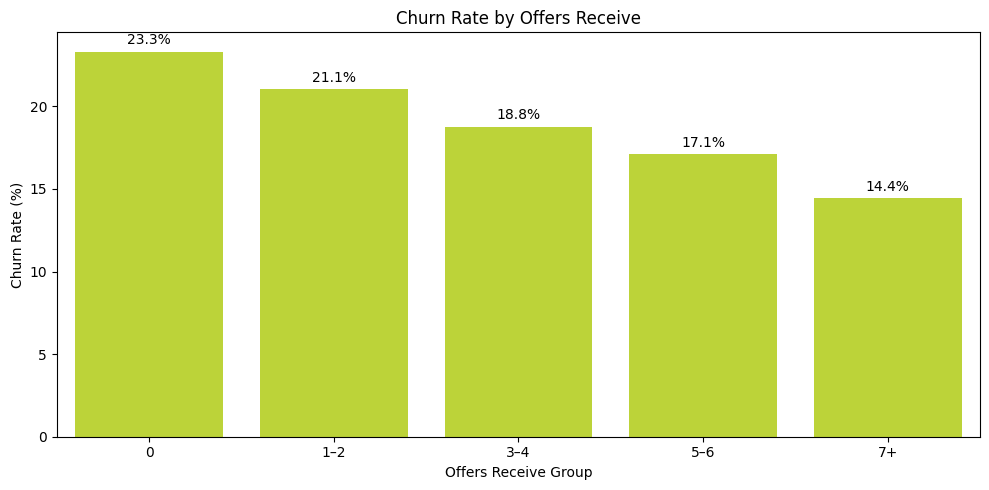

In [137]:
plt.figure(figsize=(10, 5))

bars = sns.barplot(
    data=offers_received_churn,
    x="offers_received_group",
    y="churn_rate",
    color="#ceed1f"
)

plt.title("Churn Rate by Offers Receive")
plt.xlabel("Offers Receive Group")
plt.ylabel("Churn Rate (%)")

for container in bars.containers:
    bars.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [138]:
# Offers Redeemed
df["offers_redeemed"].describe()

count    100000.00000
mean          1.05078
std           1.02474
min           0.00000
25%           0.00000
50%           1.00000
75%           2.00000
max           8.00000
Name: offers_redeemed, dtype: float64

In [139]:
bins = [-1, 0, 1, 2, float("inf")]

labels = [
    "0",
    "1",
    "2",
    "3+"
]

df["offers_redeemed_group"] = pd.cut(
    df["offers_redeemed"],
    bins=bins,
    labels=labels
)

In [140]:
offers_redeemed_churn = (
    df.groupby("offers_redeemed_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

offers_redeemed_churn["churn_rate"] *= 100

offers_redeemed_churn

,offers_redeemed_group,customers,churned,churn_rate
0,0,35000,8150,23.285714
1,1,36645,7028,19.178606
2,2,19376,3104,16.019818
3,3+,8979,1176,13.097227


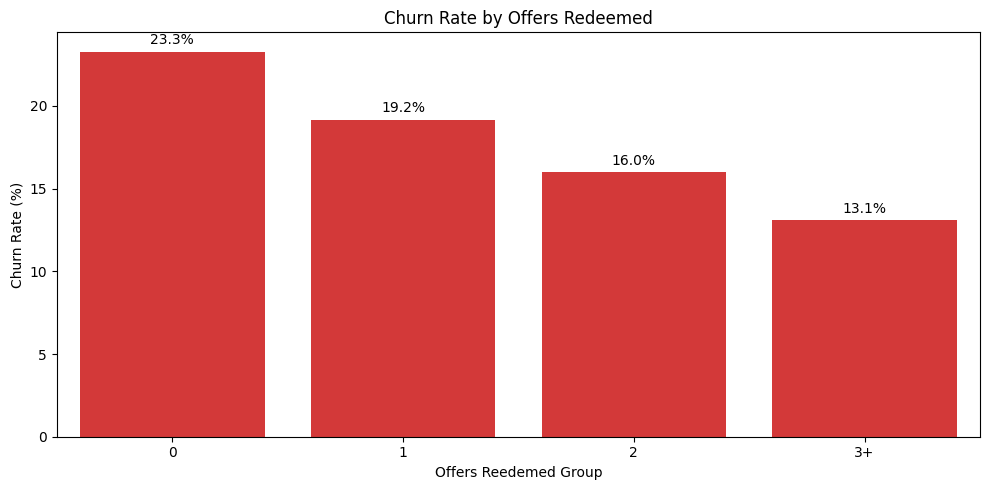

In [141]:
plt.figure(figsize=(10, 5))

bars = sns.barplot(
    data=offers_redeemed_churn,
    x="offers_redeemed_group",
    y="churn_rate",
    color="#ed1f1f"
)

plt.title("Churn Rate by Offers Redeemed")
plt.xlabel("Offers Reedemed Group")
plt.ylabel("Churn Rate (%)")

for container in bars.containers:
    bars.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [142]:
# rewards points 
df["reward_points"].describe()

count    100000.000000
mean       7017.855930
std        7494.044255
min          40.000000
25%        2323.000000
50%        4635.500000
75%        8905.000000
max       87409.000000
Name: reward_points, dtype: float64

In [143]:
bins = [0, 2500, 5000, 10000, float("inf")]

labels = [
    "<2,500",
    "2,500–5,000",
    "5,000–10,000",
    ">10,000"
]

df["reward_points_group"] = pd.cut(
    df["reward_points"],
    bins=bins,
    labels=labels
)

In [144]:
reward_points_churn = (
    df.groupby("reward_points_group", observed=False)["churned"]
      .agg(
          customers="count",
          churned="sum",
          churn_rate="mean"
      )
      .reset_index()
)

reward_points_churn["churn_rate"] *= 100

reward_points_churn

,reward_points_group,customers,churned,churn_rate
0,"<2,500",27230,4670,17.150202
1,"2,500–5,000",25824,4864,18.835192
2,"5,000–10,000",25685,5127,19.961067
3,">10,000",21261,4797,22.562438


In [160]:
df["churn_risk_score"]

0        13.00
1         4.30
2         3.32
3        19.30
4        15.10
         ...  
99995    38.13
99996     9.85
99997     8.93
99998     3.72
99999     4.53
Name: churn_risk_score, Length: 100000, dtype: float64